# Forecasting Nifty 50 Volatility

Two questions, in order:

1. Can 20-day-ahead Nifty volatility be forecast better than a zero-parameter
   baseline, and better than the market's own forecast (India VIX)?
2. If yes, is that edge worth money after transaction costs?

The answer to the first is yes. The answer to the second is no, and that
gap is the most useful result here.

**Models:** Naive, EWMA, GJR-GARCH(1,1)-t, HAR, HAR+VIX
**Loss:** QLIKE (primary), RMSE (secondary)
**Validation:** expanding-window walk-forward, refit annually, 2014-2026
**Economic test:** volatility targeting on Nifty, with costs and turnover

Notebook runs top to bottom. Parts 1-4 are exploratory and in-sample. Part 5 is
the honest statistical comparison; Part 6 is the money test.

## Naming conventions

Read these once; they are used consistently throughout.

**Units — the single most important distinction**

| Prefix | Quantity | Squared? | Typical value |
|---|---|---|---|
| `rv_*` | realized **variance**, daily | yes | 0.0001 |
| everything else (`gk_d`, `har_m`, `target`, `naive`, `vix`) | **volatility**, annualised | no | 0.16 = 16% |

Variance is what gets summed and averaged, because variance is additive across
time and across independent components. Volatility only appears at the end, via
`np.sqrt(mean_variance * 252)`. Averaging volatility directly would be wrong.

**Column names**

| Name | Meaning |
|---|---|
| `log_ret` | daily log return |
| `rv_daily` | close-to-close variance, `log_ret**2` |
| `rv_park` | Parkinson variance, from the daily high/low range |
| `rv_gk` | Garman-Klass variance, intraday only |
| `rv_overnight` | variance of the open-vs-previous-close gap |
| `rv_gk_full` | `rv_gk + rv_overnight` — the estimator actually used |
| `rv_20` | 20-day trailing realized volatility (the measurement) |
| `target` | 20-day **forward** realized volatility (the outcome to predict) |
| `naive` | baseline forecast; identical to `rv_20` by construction |
| `vix` | India VIX, divided by 100 so it matches our units |

**Feature suffixes** — `_d` / `_w` / `_m` are the 1 / 5 / 22-day windows,
`_neg` is the down-days-only version used for the leverage effect.

| Family | Built from | Used for |
|---|---|---|
| `har_d`, `har_w`, `har_m`, `har_neg` | `rv_daily` | close-to-close HAR, kept for the estimator comparison in 3.4 |
| `gk_d`, `gk_w`, `gk_m`, `gk_neg` | `rv_gk_full` | the HAR features actually used from Part 4 on |

**Abbreviations**

| Term | Meaning |
|---|---|
| RV | realized volatility |
| HAR | Heterogeneous Autoregressive |
| HAR-L | HAR plus the leverage (down-day) feature |
| GJR | Glosten-Jagannathan-Runkle, the asymmetric GARCH variant |
| GK | Garman-Klass |
| QLIKE | quasi-likelihood loss, the primary scoring function |
| DM | Diebold-Mariano, the test for whether two models' losses differ |
| HAC | heteroskedasticity- and autocorrelation-consistent standard errors |
| VRP | volatility risk premium, implied minus subsequently realized |
| OOS | out-of-sample |
| bps | basis points, 1bp = 0.01% |

**DataFrames**

| Name | Contents |
|---|---|
| `df` | everything, raw prices through features, with NaNs |
| `data` | `df` with NaNs dropped — the in-sample modelling frame |
| `wf` | walk-forward out-of-sample forecasts, one column per model |
| `bt_*` | backtest frames: returns, leverage, turnover, costs |

---
# Part 1. Data and evidence

## 1.1 Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
from scipy.stats import binomtest

pd.set_option("display.width", 130)

HORIZON   = 20            # forecast horizon, trading days
ANNUALISE = np.sqrt(252)  # daily vol -> annualised vol
START     = "2007-01-01"

# Figures are written here for the README. Path is relative to notebooks/.
FIGDIR = Path("../figures")
FIGDIR.mkdir(exist_ok=True)

nifty = yf.download("^NSEI", start=START, auto_adjust=True, multi_level_index=False)
vix   = yf.download("^INDIAVIX", start=START, auto_adjust=True, multi_level_index=False)

df = nifty[["Open", "High", "Low", "Close"]].copy()
df.columns = ["open", "high", "low", "close"]
df["vix"] = vix["Close"] / 100          # percent -> decimal, same units as our vol

# Log returns rather than simple returns: they add across time, so variance
# scales linearly and the sqrt(252) annualisation below is valid.
df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
df = df.iloc[1:]                         # first row has no return

print(f"Nifty : {len(df)} days | {df.index[0].date()} to {df.index[-1].date()}")
print(f"VIX   : available from {df['vix'].first_valid_index().date()},"
      f" {df['vix'].isna().sum()} missing days")
df.tail(3)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Nifty : 4659 days | 2007-09-18 to 2026-09-15
VIX   : available from 2008-03-03, 134 missing days


,open,high,low,close,vix,log_ret
Date,,,,,,
2026-09-10,23446.599609,23494.949219,23380.099609,23477.800781,0.118000,0.001974
2026-09-11,23270.300781,23448.099609,23231.400391,23398.099609,0.122900,-0.003401
2026-09-15,23576.150391,23592.849609,23118.599609,23118.599609,0.134325,-0.012017


## 1.2 Is volatility forecastable at all?

Same test on two series. Returns carry the *direction* of each move; squared
returns strip the sign and leave the *magnitude*. If the two look different,
direction and magnitude have different predictability — and that decides what
this project is about.

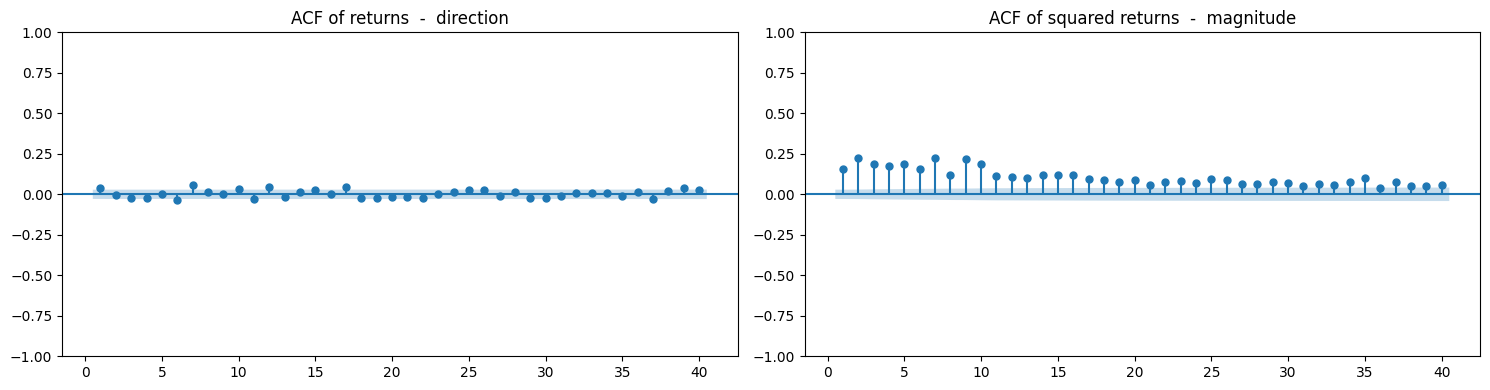

  lag    returns    squared
    1     0.0372     0.1589
    5     0.0037     0.1878
   22    -0.0232     0.0771
   40     0.0256     0.0555


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

plot_acf(df["log_ret"], lags=40, zero=False, ax=axes[0])
axes[0].set_title("ACF of returns  -  direction")

plot_acf(df["log_ret"] ** 2, lags=40, zero=False, ax=axes[1])
axes[1].set_title("ACF of squared returns  -  magnitude")

plt.tight_layout()
plt.savefig(FIGDIR / "acf_returns_vs_squared.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'lag':>5} {'returns':>10} {'squared':>10}")
for lag in [1, 5, 22, 40]:
    print(f"{lag:>5} {df['log_ret'].autocorr(lag):>10.4f}"
          f" {(df['log_ret'] ** 2).autocorr(lag):>10.4f}")

**Returns have no memory.** All autocorrelations below 0.06. A few lags breach
the 5% band, but at about the rate expected from testing 40 lags at once, at
scattered lags with no economic story.

**Volatility has a long memory.** Squared-return autocorrelation starts near
0.25 and is still positive at lag 40.

A predictable direction gets arbitraged away — everyone buys today and the move
disappears. Predictable turbulence cannot be, because knowing *that* next week
is violent without knowing *which way* gives you no position to take.

So: forecast how violently the market moves, not where it goes.

---
# Part 2. Measuring volatility

Before forecasting it, measure it properly. Close-to-close uses two points a day
and throws away everything in between — a day that opens at 100, runs to 105,
falls to 96 and closes at 100 registers as *zero*.

Range-based estimators use the high and low:

- **Parkinson (1980)** — `[ln(H/L)]^2 / (4 ln 2)`, about 5x more efficient
- **Garman-Klass (1980)** — adds open-to-close, about 7.4x more efficient

Both assume prices move continuously, so both miss the **overnight gap**. That
matters more in India than in the US: global markets trade while the NSE is
shut, and Nifty gaps at the open.

In [3]:
# Every rv_* column below is daily VARIANCE (squared), not volatility.
# Variance is additive, which is what lets rv_gk and rv_overnight be summed
# and what makes the rolling means further down valid. Volatility appears
# only after np.sqrt(), when the HAR features are built.
hl = np.log(df["high"] / df["low"])
co = np.log(df["close"] / df["open"])

df["rv_park"]      = hl ** 2 / (4 * np.log(2))
df["rv_gk"]        = 0.5 * hl ** 2 - (2 * np.log(2) - 1) * co ** 2
df["rv_overnight"] = np.log(df["open"] / df["close"].shift(1)) ** 2
df["rv_gk_full"]   = df["rv_gk"] + df["rv_overnight"]   # intraday + gap

est = ["rv_park", "rv_gk", "rv_gk_full"]
lvl = df[est].apply(lambda s: np.sqrt(s.mean() * 252) * 100)
lvl["close-to-close"] = df["log_ret"].std() * ANNUALISE * 100
print(lvl.round(2).to_string())

# Variance is additive, so the overnight share is computable
v_intra, v_full = df["rv_gk"].mean(), df["rv_gk_full"].mean()
print(f"\novernight share of total variance: {(v_full - v_intra) / v_full * 100:.1f}%")

rv_park           17.56
rv_gk             17.16
rv_gk_full        19.56
close-to-close    20.54

overnight share of total variance: 23.0%


**A large share of Nifty variance is created overnight**, while the exchange is
closed — see the figure printed above. Plain Parkinson or Garman-Klass therefore
*understate* Indian equity risk by roughly that much. Using either without an
overnight term is a mistake on this market.

Close-to-close reads highest of the four. That is not because it is right: it is
a far noisier estimator, and volatility is right-skewed, so noise pulls its mean
up. The Garman-Klass figure including the gap is probably closer to the truth.

`rv_gk_full` is used for features from here on.

---
# Part 3. Target, baseline and loss function

## 3.1 The prediction problem

`rv_20` measures the **last** 20 days. `target` is the same thing over the
**next** 20 days — the outcome to predict. `shift(-HORIZON)` pulls that future
value onto today's row so forecast and outcome sit side by side.

The baseline is `rv_20` itself: *whatever volatility is now, it stays.* Zero
parameters. Everything below has to beat it.

The target stays **close-to-close** even though `rv_gk_full` is a cleaner
measurement, because close-to-close is what actually shows up in a portfolio's
P&L. A GK-based target was also tested (Part 3.4) and changed nothing.

In [4]:
# rv_20 and target are VOLATILITY (annualised), not variance — .std() already
# took the square root. Everything from here on is in volatility units.
df["rv_20"]  = df["log_ret"].rolling(HORIZON).std() * ANNUALISE
df["target"] = df["rv_20"].shift(-HORIZON)   # negative shift = look forward
df["naive"]  = df["rv_20"]                   # baseline forecast

# --- features, all built once on df so the notebook re-runs cleanly ---------

# Close-to-close HAR features (kept for the estimator comparison in 3.4)
df["rv_daily"] = df["log_ret"] ** 2
df["har_d"] = np.sqrt(df["rv_daily"].rolling(1).mean()  * 252)
df["har_w"] = np.sqrt(df["rv_daily"].rolling(5).mean()  * 252)
df["har_m"] = np.sqrt(df["rv_daily"].rolling(22).mean() * 252)

# Garman-Klass HAR features: three genuinely different windows, 1 / 5 / 22 days.
# Order matters: average the VARIANCE first, annualise, then take the square
# root. Averaging volatility directly understates it (Jensen's inequality).
df["gk_d"] = np.sqrt(df["rv_gk_full"].rolling(1).mean()  * 252)
df["gk_w"] = np.sqrt(df["rv_gk_full"].rolling(5).mean()  * 252)
df["gk_m"] = np.sqrt(df["rv_gk_full"].rolling(22).mean() * 252)

# Leverage features: variance contributed by down days only
df["har_neg"] = np.sqrt(df["rv_daily"].where(df["log_ret"] < 0, 0)
                        .rolling(22).mean() * 252)
df["gk_neg"]  = np.sqrt(df["rv_gk_full"].where(df["log_ret"] < 0, 0)
                        .rolling(22).mean() * 252)

# A flat day, or a 22-day window with no down days, would give log(0)
FEATS = ["har_d", "har_w", "har_m", "har_neg", "gk_d", "gk_w", "gk_m", "gk_neg"]
df[FEATS] = df[FEATS].clip(lower=1e-6)

# Alignment is the most dangerous bug here — an off-by-one shift makes a model
# look brilliant because it is reading the future. Assert, don't trust.
chk = df[["rv_20", "target"]].dropna()
assert np.isclose(chk["target"].iloc[100], chk["rv_20"].iloc[100 + HORIZON])
print("alignment check passed")

alignment check passed


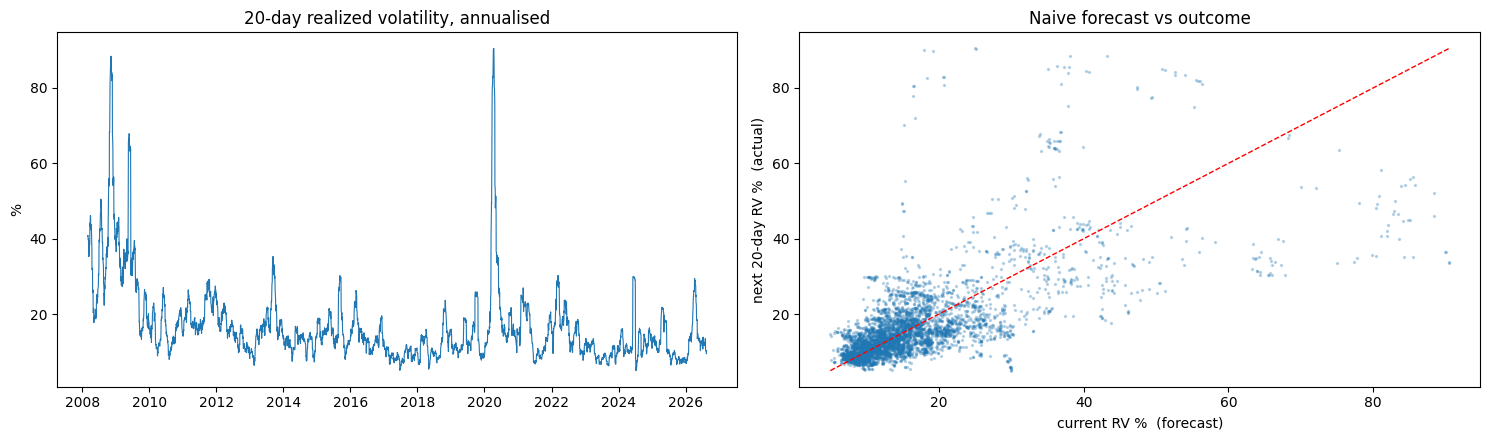

4505 rows | 2008-03-03 to 2026-08-17
correlation 0.653   R-squared 0.426
mean realized volatility 16.72%


In [5]:
data = df[["log_ret", "rv_20", "target", "naive", "vix"] + FEATS].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(data.index, data["rv_20"] * 100, linewidth=0.8)
axes[0].set_title("20-day realized volatility, annualised")
axes[0].set_ylabel("%")

axes[1].scatter(data["naive"] * 100, data["target"] * 100, s=2, alpha=0.25)
lo = min(data["naive"].min(), data["target"].min()) * 100
hi = max(data["naive"].max(), data["target"].max()) * 100
axes[1].plot([lo, hi], [lo, hi], "r--", linewidth=1)   # perfect-forecast line
axes[1].set_xlabel("current RV %  (forecast)")
axes[1].set_ylabel("next 20-day RV %  (actual)")
axes[1].set_title("Naive forecast vs outcome")

plt.tight_layout()
plt.savefig(FIGDIR / "realized_vol_and_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

corr = data["naive"].corr(data["target"])
print(f"{len(data)} rows | {data.index[0].date()} to {data.index[-1].date()}")
print(f"correlation {corr:.3f}   R-squared {corr ** 2:.3f}")
print(f"mean realized volatility {data['target'].mean() * 100:.2f}%")

Roughly 40% of future volatility is explained by current volatility alone, with
nothing fitted. The same number for *returns* is near zero — a difference of
two to three orders of magnitude in predictability between the first and second
moment of one series.

That figure is the bar to beat, not an achievement.

The sample starts in 2008, because India VIX does. Every model below is compared
on identical rows.

## 3.2 Where the baseline fails

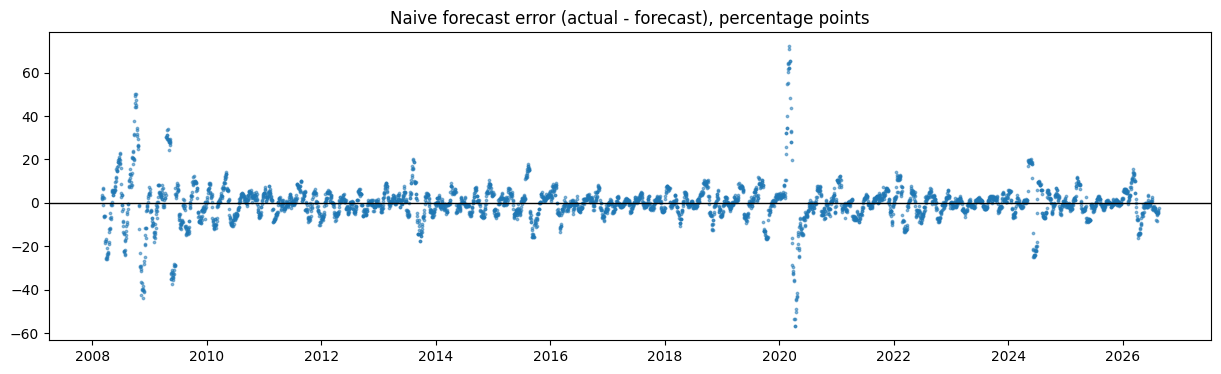

mean positive error      5.08
mean negative error     -5.32
largest positive        72.09
largest negative       -56.88
median |error|           3.11
skew                    0.711


In [6]:
data["error"] = data["target"] - data["naive"]

plt.figure(figsize=(15, 4))
plt.scatter(data.index, data["error"] * 100, s=3, alpha=0.5)
plt.axhline(0, color="black", linewidth=1)
plt.title("Naive forecast error (actual - forecast), percentage points")
plt.show()

e = data["error"] * 100
print(f"mean positive error  {e[e > 0].mean():>8.2f}")
print(f"mean negative error  {e[e < 0].mean():>8.2f}")
print(f"largest positive     {e.max():>8.2f}")
print(f"largest negative     {e.min():>8.2f}")
print(f"median |error|       {e.abs().median():>8.2f}")
print(f"skew                 {data['error'].skew():>8.3f}")

**Error size scales with the volatility level.** Three to four points in calm
markets, sixty-plus in crises. RMSE squares them, so one crisis day carries the
weight of about 400 calm days — an RMSE comparison here is really a comparison
over March 2020 alone.

So the primary loss is **QLIKE**, which works on the ratio `actual/forecast`
instead of the difference, and therefore scores a 3-point miss at 15% vol the
same as a 14-point miss at 70%. It also penalises under-forecasting more than
over-forecasting, matching the economics: being short of risk before a crash
costs far more than carrying extra cushion through a calm month.

**Errors are asymmetric (skew ≈ 0.8).** Negative errors are frequent but small,
positive ones rare and enormous — volatility spikes fast and decays slowly. The
slow decay is why the baseline over-forecasts after every spike: it has no
normal level to return to. Every model below adds mean reversion in some form.

## 3.3 Loss functions and the significance test

In [7]:
def rmse(actual, forecast):
    """Root mean squared error, in volatility units."""
    return np.sqrt(np.mean((actual - forecast) ** 2))


def qlike(actual, forecast):
    """QLIKE loss on variances. Zero for a perfect forecast, lower is better.

    Scale-free (works on the ratio) and asymmetric (punishes under-forecasting
    harder). No absolute meaning — only differences between models matter.
    """
    a, f = actual ** 2, forecast ** 2
    if np.any(a <= 0) or np.any(f <= 0):
        raise ValueError("zero or negative values passed to qlike")
    ratio = a / f
    return np.mean(ratio - np.log(ratio) - 1)


def qlike_series(actual, forecast):
    """Per-observation QLIKE, for yearly breakdowns and significance tests."""
    ratio = actual ** 2 / forecast ** 2
    return ratio - np.log(ratio) - 1


def diebold_mariano(loss_a, loss_b, lags=HORIZON):
    """Test whether two models' mean losses genuinely differ.

    HAC errors are essential: the 20-day targets overlap, so consecutive rows
    share 19 of 20 days. An uncorrected t-test on this data returns t ~ 12,
    which is meaningless — 3,000 rows of overlapping windows hold only ~150
    independent observations. HAC brings it down to something honest.

    Returns (mean loss difference, t-statistic, p-value).
    """
    d = (loss_a - loss_b).dropna()
    reg = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return (float(reg.params.iloc[0]),
            float(reg.tvalues.iloc[0]),
            float(reg.pvalues.iloc[0]))


def fit_har(frame, features, horizon_lags=HORIZON):
    """Fit a HAR-type model in log space with HAC errors. Returns (model, forecast).

    Logs because volatility is right-skewed and its errors scale with its level.

    The + sigma2/2 is not cosmetic: exp(prediction) recovers the MEDIAN of a
    log-normal, not the mean, so the forecast comes out about 6% low on this
    data. QLIKE punishes under-forecasting harder, so the bias gets charged
    twice. Fixing it improved HAR's QLIKE by 8.4% — comparable to the entire
    gain from switching models.

    Worth checking on any log-transformed target: compare mean(forecast) against
    mean(actual). Two lines, catches a whole class of silent bugs.
    """
    X = sm.add_constant(np.log(frame[features]))
    y = np.log(frame["target"])
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": horizon_lags})
    return m, np.exp(m.predict(X) + m.resid.var() / 2)


print(f"Naive RMSE   {rmse(data['target'], data['naive']):.4f}")
print(f"Naive QLIKE  {qlike(data['target'], data['naive']):.4f}   <- the number to beat")

Naive RMSE   0.0884
Naive QLIKE  0.3207   <- the number to beat


## 3.4 Does a cleaner estimator help?

Two ways to use Garman-Klass: as **features** (predict the same close-to-close
target from cleaner inputs), or as the **target** itself. Both are tested.

Only the first comparison is like-for-like — changing the target changes the
scale of QLIKE, so those numbers are compared as *percent improvement over the
matching baseline*, not directly.

In [8]:
har_cc = ["har_d", "har_w", "har_m"]
har_gk = ["gk_d",  "gk_w",  "gk_m"]

m_cc, fc_cc = fit_har(data, har_cc)
m_gk, fc_gk = fit_har(data, har_gk)

comp = pd.DataFrame({
    "close-to-close": [m_cc.params[c] for c in har_cc]
                      + [m_cc.pvalues[har_cc[0]], m_cc.params[har_cc].sum(),
                         qlike(data["target"], fc_cc)],
    "Garman-Klass":   [m_gk.params[c] for c in har_gk]
                      + [m_gk.pvalues[har_gk[0]], m_gk.params[har_gk].sum(),
                         qlike(data["target"], fc_gk)],
}, index=["daily coef", "weekly coef", "monthly coef",
          "daily p-value", "coef sum", "QLIKE"])
print(comp.round(4).to_string())

# Same features, but a GK-based target — does cleaner measurement raise the
# ceiling, or only reduce noise?
gk_t = df[["rv_gk_full"] + har_gk].copy()
gk_t["rv20_gk"]  = np.sqrt(gk_t["rv_gk_full"].rolling(HORIZON).mean() * 252)
gk_t["naive_gk"] = gk_t["rv20_gk"]
gk_t["target"]   = gk_t["rv20_gk"].shift(-HORIZON)
gk_t = gk_t.dropna()

_, fc_gkt = fit_har(gk_t, har_gk)
q_nv, q_hr = qlike(gk_t["target"], gk_t["naive_gk"]), qlike(gk_t["target"], fc_gkt)

print(f"\ncc target : HAR beats naive by "
      f"{(1 - qlike(data['target'], fc_gk) / qlike(data['target'], data['naive'])) * 100:.1f}%")
print(f"GK target : HAR beats naive by {(1 - q_hr / q_nv) * 100:.1f}%")

               close-to-close  Garman-Klass
daily coef             0.0061        0.1402
weekly coef            0.1796        0.2619
monthly coef           0.5359        0.3997
daily p-value          0.1322        0.0000
coef sum               0.7216        0.8019
QLIKE                  0.2592        0.2535

cc target : HAR beats naive by 21.0%
GK target : HAR beats naive by 21.9%


**The daily term was measurement noise, not absence of information.** With
close-to-close features the daily coefficient is near zero and insignificant,
which reads like "one day tells you nothing over a 20-day horizon." With
Garman-Klass the same term is an order of magnitude larger and strongly
significant — see the `daily p-value` row above.

A single day of close-to-close variance is so noisy that the signal inside it
was drowned. The efficient estimator recovers it. Coefficient weight also
spreads across all three timescales instead of piling onto the monthly term,
which is what HAR was designed to do.

**Switching the target changes almost nothing.** Improvement over the matching
baseline is about the same either way. Cleaner measurement makes the *ruler*
better, not the *phenomenon* more predictable — and a clean confirmation that
the improvement is real signal rather than an artifact of a noisy target.

The target stays close-to-close from here, because that is the quantity that
shows up in a portfolio's P&L.

---
# Part 4. Models

Everything in this part is fitted on the full sample and scored on the same
data, so the numbers are optimistic. They are kept because the **parameters**
carry findings. Part 5 redoes the comparison honestly.

## 4.1 EWMA

`var_t = lam * var_(t-1) + (1 - lam) * r2_(t-1)`

A rolling window weights the last 20 days equally then drops day 21 to zero,
which makes the estimate lurch when an old shock exits the window even though
nothing happened. EWMA decays weights geometrically instead.

`lam = 0.94` is the RiskMetrics convention, taken as given rather than tuned, so
EWMA — like the baseline — has nothing fitted to this sample.

In [9]:
def ewma_variance(returns, lam=0.94, burn=250):
    """Daily conditional variance by exponentially weighted moving average.

    The append comes BEFORE the update on purpose. The value appended was built
    from information through yesterday only, which is today's forecast. Swapping
    those two lines injects today's return into today's forecast — lookahead
    bias, and the most common bug in this field.
    """
    var = np.var(returns[:burn])          # starting guess, decays away in ~250 days
    out = []
    for r in returns:
        out.append(var)                          # forecast for today
        var = lam * var + (1 - lam) * r ** 2     # update for tomorrow
    return np.array(out)


data["ewma_fc"] = np.sqrt(ewma_variance(data["log_ret"].values)) * ANNUALISE

print(f"EWMA range {data['ewma_fc'].min() * 100:.1f}% to {data['ewma_fc'].max() * 100:.1f}%")
print(f"EWMA mean  {data['ewma_fc'].mean() * 100:.2f}%"
      f"   vs actual mean {data['target'].mean() * 100:.2f}%")
print(f"EWMA QLIKE {qlike(data['target'], data['ewma_fc']):.4f}")

EWMA range 6.8% to 78.5%
EWMA mean  17.34%   vs actual mean 16.72%
EWMA QLIKE 0.2995


## 4.2 GJR-GARCH(1,1) with Student-t errors

`var_t = omega + (alpha + gamma*I) * r2_(t-1) + beta * var_(t-1)`,
where `I = 1` if yesterday's return was negative.

Three additions over EWMA: `omega` anchors the process to a long-run level so
forecasts mean-revert; `gamma` lets falls raise volatility more than rises;
Student-t errors instead of normal, because equity returns have fat tails.

Set `omega = 0`, `gamma = 0`, `alpha + beta = 1` and GARCH collapses into EWMA.

In [10]:
gjr = arch_model(data["log_ret"] * 100, mean="Zero", vol="GARCH",
                 p=1, o=1, q=1, dist="t").fit(disp="off")
print(gjr.summary())

p = gjr.params

# gamma only fires on down days (~half the sample), so its average effect is /2
persistence = p["alpha[1]"] + 0.5 * p["gamma[1]"] + p["beta[1]"]
lr_vol = np.sqrt(p["omega"] / (1 - persistence)) * ANNUALISE

print(f"\nalpha  (up days)        {p['alpha[1]']:.4f}    p = {gjr.pvalues['alpha[1]']:.3f}")
print(f"gamma  (extra on down)  {p['gamma[1]']:.4f}    p = {gjr.pvalues['gamma[1]']:.2e}")
print(f"down/up impact ratio    {(p['alpha[1]'] + p['gamma[1]']) / p['alpha[1]']:.1f}x")
print(f"\npersistence             {persistence:.4f}")
print(f"shock half-life         {np.log(0.5) / np.log(persistence):.0f} trading days")
print(f"long-run volatility     {lr_vol:.2f}%"
      f"    (sample mean {data['target'].mean() * 100:.2f}%)")

# Does the asymmetry term earn the extra parameter it costs?
plain = arch_model(data["log_ret"] * 100, mean="Zero", vol="GARCH",
                   p=1, o=0, q=1, dist="t").fit(disp="off")
print(f"\nBIC   plain GARCH {plain.bic:.1f}   vs   GJR {gjr.bic:.1f}")

                        Zero Mean - GJR-GARCH Model Results                         
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -6284.99
Distribution:      Standardized Student's t   AIC:                           12580.0
Method:                  Maximum Likelihood   BIC:                           12612.0
                                              No. Observations:                 4505
Date:                      Tue, Sep 15 2026   Df Residuals:                     4505
Time:                              21:34:42   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

**Nifty volatility is made almost entirely of falls.** `alpha` is insignificant
while `gamma` is overwhelming (p ~ 1e-12) and roughly 17x larger. Rallies leave
volatility about where it was. BIC drops sharply when the asymmetry term is
added, so it is not a free-parameter artifact.

**Persistence ~0.98**, a half-life near 43 trading days. Shocks survive for
months — the same long memory the ACF showed in Part 1.

**Sanity check:** long-run volatility lands close to the sample mean. That is
the main check that nothing is broken in the scaling.

`conditional_volatility` is a 1-day estimate while the target is 20-day. That
mismatch is fixed properly in Part 5.

## 4.3 HAR and the leverage feature

`log RV_(t+20) = b0 + bd*log RV_d + bw*log RV_w + bm*log RV_m`

GARCH decays at a single rate, giving an exponential ACF. The observed ACF
decays much more slowly. HAR approximates that long memory by summing three
timescales — roughly the horizons day traders, portfolio managers and
institutions operate on.

HAR-L adds a fourth feature, variance from *down days only*, giving HAR the
leverage effect GARCH gets from gamma.

In [11]:
gk_l = har_gk + ["gk_neg"]

m_har,  fc_har  = fit_har(data, har_gk)
m_harl, fc_harl = fit_har(data, gk_l)

data["har_fc"]  = fc_har
data["harl_fc"] = fc_harl

print(m_harl.summary())
print(f"\nBIC    HAR {m_har.bic:.1f}   vs   HAR-L {m_harl.bic:.1f}")
print(f"QLIKE  HAR {qlike(data['target'], fc_har):.4f}"
      f"   vs   HAR-L {qlike(data['target'], fc_harl):.4f}")
print(f"\ncoefficient sum  {m_har.params[har_gk].sum():.3f}   (below 1 = mean reversion)")
print(f"mean forecast {fc_har.mean() * 100:.2f}%"
      f"   vs actual {data['target'].mean() * 100:.2f}%   <- log-normal bias check")

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     98.38
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           2.19e-80
Time:                        21:34:42   Log-Likelihood:                -1262.9
No. Observations:                4505   AIC:                             2536.
Df Residuals:                    4500   BIC:                             2568.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3282      0.096     -3.420      0.0

**Mean reversion, confirmed a third time.** HAR's coefficients sum well below 1.
The same property appeared as GARCH's `omega` anchor and as a slope below 1 in a
plain regression of future on current RV. Three unrelated models agreeing makes
it a property of the market, not an artifact of any one of them.

**The leverage effect does not survive to a 20-day horizon.** In GJR-GARCH the
asymmetry term is one of the strongest parameters in the model (p ~ 1e-12). The
same effect as a HAR feature is *insignificant* (p ≈ 0.20), and HAR-L's
out-of-sample QLIKE is indistinguishable from plain HAR.

BIC mildly prefers HAR-L, so the feature is not pure noise — but a coefficient
that dominates at one day and vanishes at twenty is a warning about importing a
daily risk model into a monthly one. Falls drive volatility *tomorrow*; a month
out, mean reversion has washed the asymmetry away.

Plain HAR is carried forward as the representative HAR model. When two models
are statistically indistinguishable, the simpler one generalises better.

---
# Part 5. The market's own forecast

Every comparison so far has been against a baseline we constructed. The real
competitor is **India VIX** — a 30-day implied volatility forecast priced by
thousands of participants with money at stake.

If VIX beats these models, they are academic. If they add something to VIX, the
edge is real.

In [12]:
v = data[["vix", "target"]].dropna()

print(f"VIX mean      {v['vix'].mean() * 100:.2f}%")
print(f"realized mean {v['target'].mean() * 100:.2f}%")
print(f"VRP           {(v['vix'].mean() - v['target'].mean()) * 100:.2f} points"
      f"   ({(v['vix'].mean() / v['target'].mean() - 1) * 100:.0f}% premium)")

print(f"\nRaw VIX QLIKE {qlike(v['target'], v['vix']):.4f}")

# Strip the premium and see what is left
Xv = sm.add_constant(np.log(v["vix"]))
m_vix = sm.OLS(np.log(v["target"]), Xv).fit(cov_type="HAC", cov_kwds={"maxlags": HORIZON})
vix_fc = np.exp(m_vix.predict(Xv) + m_vix.resid.var() / 2)
print(f"De-biased VIX QLIKE {qlike(v['target'], vix_fc):.4f}")
print(m_vix.summary())

VIX mean      19.75%
realized mean 16.72%
VRP           3.03 points   (18% premium)

Raw VIX QLIKE 0.2486
De-biased VIX QLIKE 0.2402
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     454.8
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           3.16e-96
Time:                        21:34:42   Log-Likelihood:                -922.88
No. Observations:                4505   AIC:                             1850.
Df Residuals:                    4503   BIC:                             1863.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975

**India VIX runs about 3 points above subsequently realized volatility**, an
~18% premium. That is the **volatility risk premium** — the compensation option
sellers earn for carrying crash risk, not a market error. Insurance costs more
than expected claims, or nobody would write it.

**The slope is ~0.98, with 1.0 inside the confidence interval.** VIX scales
moves almost exactly right; the entire bias sits in the intercept. So implied
volatility is a *correctly shaped* forecast with a constant multiplicative
premium on top — strong evidence of an efficient options market.

The temptation now is "sell options, collect 18%." That premium is payment for
tail risk: the strategy earns small amounts for years and gives it all back in
one crash. It is compensation, not an inefficiency.

In [13]:
enc = data[["vix", "har_fc", "target"]].dropna().copy()

X = sm.add_constant(pd.DataFrame({"log_har": np.log(enc["har_fc"]),
                                  "log_vix": np.log(enc["vix"])}, index=enc.index))
m_enc = sm.OLS(np.log(enc["target"]), X).fit(cov_type="HAC",
                                             cov_kwds={"maxlags": HORIZON})
print(m_enc.summary())

combo_fc = np.exp(m_enc.predict(X) + m_enc.resid.var() / 2)

print(f"\nHAR alone   {qlike(enc['target'], enc['har_fc']):.4f}")
print(f"VIX alone   {qlike(enc['target'], vix_fc.reindex(enc.index)):.4f}")
print(f"HAR + VIX   {qlike(enc['target'], combo_fc):.4f}")

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     267.3
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          2.10e-110
Time:                        21:34:42   Log-Likelihood:                -836.37
No. Observations:                4505   AIC:                             1679.
Df Residuals:                    4502   BIC:                             1698.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0766      0.093     -0.826      0.4

**Neither forecast encompasses the other** — both coefficients are strongly
significant, and the combination beats each alone.

That makes sense. VIX is forward-looking: it prices known upcoming events,
election dates, earnings, expiry, global risk sentiment. HAR is backward-looking:
it reads realized structure, persistence and the current regime. Different
information, and they add.

**The intercept becomes insignificant once HAR is included.** Alone, VIX carried
a large significant bias. Adding HAR absorbs it. So part of what looked like a
pure risk premium was actually an information gap — VIX was over-pricing partly
because it lacked what realized volatility already knew.

Weights land near 70% VIX / 30% HAR. The honest framing is that the market's
forecast is primary and this model is a correction to it.

---
# Part 6. Walk-forward validation

Everything above let each model see the whole sample, including the future it
was scored against. GARCH's parameters for a 2010 forecast were informed by
2020. In live use that information does not exist.

Here each model is refit at the start of every year on data available by then,
then scored on that year out-of-sample. Two details decide whether this is
honest:

- Training drops its last 20 rows — those targets are built from returns inside
  the test year, so keeping them leaks the future.
- GARCH parameters are frozen per year, then the variance recursion rolls
  forward on realised returns. Nobody refits GARCH daily in production.

GARCH also gets a genuine 20-step-ahead forecast here, averaging h-step
variances that decay toward the long-run level, rather than the 1-day
`conditional_volatility` used in Part 4.

In [14]:
SPECS = {                       # name -> feature columns, refit each year
    "har":   har_gk,
    "har_l": gk_l,
    "vix":   ["vix"],
    "combo": har_gk + ["vix"],
}


def walk_forward(frame, start_year=2014, horizon=HORIZON):
    """Expanding-window walk-forward for every log-linear model in SPECS.

    naive, EWMA and raw VIX have nothing fitted, so they pass straight through
    and act as free benchmarks.
    """
    d = frame.dropna()
    out = []

    for year in sorted(y for y in d.index.year.unique() if y >= start_year):
        train = d[d.index.year <  year].iloc[:-horizon]   # gap prevents leakage
        test  = d[d.index.year == year]
        if len(train) < 500 or len(test) == 0:
            continue

        preds = {"target":  test["target"],
                 "naive":   test["naive"],
                 "ewma":    test["ewma_fc"],
                 "vix_raw": test["vix"]}

        for name, cols in SPECS.items():
            X_tr = sm.add_constant(np.log(train[cols]))
            m = sm.OLS(np.log(train["target"]), X_tr).fit()
            X_te = sm.add_constant(np.log(test[cols]), has_constant="add")
            preds[name] = np.exp(m.predict(X_te) + m.resid.var() / 2)

        out.append(pd.DataFrame(preds, index=test.index))

    return pd.concat(out)


def walk_forward_garch(frame, start_year=2014, horizon=HORIZON):
    """GJR-GARCH refit annually; parameters frozen, variance rolled forward.

    The h-step forecast decays from today's variance toward the long-run level
    at rate persistence^h. Averaging h = 1..20 gives expected variance over the
    next 20 days, which is what the target actually measures.
    """
    out = []

    for year in sorted(y for y in frame.index.year.unique() if y >= start_year):
        train = frame[frame.index.year <  year]
        test  = frame[frame.index.year == year]
        if len(train) < 500 or len(test) == 0:
            continue

        res = arch_model(train["log_ret"] * 100, mean="Zero", vol="GARCH",
                         p=1, o=1, q=1, dist="t").fit(disp="off")
        pr = res.params

        pers   = pr["alpha[1]"] + 0.5 * pr["gamma[1]"] + pr["beta[1]"]
        lr_var = pr["omega"] / (1 - pers)
        decay  = np.array([pers ** h for h in range(1, horizon + 1)])

        var, vals = res.conditional_volatility.iloc[-1] ** 2, []
        for ret in (test["log_ret"] * 100).values:
            vals.append(np.sqrt(max(np.mean(lr_var + decay * (var - lr_var)), 1e-8))
                        / 100 * ANNUALISE)
            I = 1.0 if ret < 0 else 0.0     # asymmetry switch
            var = (pr["omega"] + (pr["alpha[1]"] + pr["gamma[1]"] * I) * ret ** 2
                   + pr["beta[1]"] * var)

        out.append(pd.Series(vals, index=test.index))

    return pd.concat(out)

In [15]:
wf = walk_forward(data)
wf["garch"] = walk_forward_garch(data)
wf = wf.dropna()

MODELS = ["naive", "ewma", "garch", "har", "har_l", "vix_raw", "vix", "combo"]

oos = pd.DataFrame({
    "QLIKE": [qlike(wf["target"], wf[m]) for m in MODELS],
    "RMSE":  [rmse(wf["target"], wf[m])  for m in MODELS],
}, index=MODELS)
oos["vs naive %"] = (1 - oos["QLIKE"] / oos.loc["naive", "QLIKE"]) * 100

print(f"{len(wf)} out-of-sample days | {wf.index[0].date()} to {wf.index[-1].date()}\n")
print(oos.round(4).sort_values("QLIKE").to_string())

3084 out-of-sample days | 2014-01-02 to 2026-08-17

          QLIKE    RMSE  vs naive %
combo    0.2611  0.0628     26.5543
vix_raw  0.2702  0.0700     23.9898
vix      0.2724  0.0637     23.3790
har_l    0.2739  0.0677     22.9581
har      0.2744  0.0674     22.8226
garch    0.2867  0.0761     19.3740
ewma     0.3411  0.0768      4.0542
naive    0.3555  0.0788      0.0000


In [16]:
for m in MODELS:
    wf["ql_" + m] = qlike_series(wf["target"], wf[m])

yearly = wf.groupby(wf.index.year)[["ql_" + m for m in MODELS]].mean()
yearly["mean_vol_%"] = wf.groupby(wf.index.year)["target"].mean() * 100
print(yearly.round(4).to_string())

# An aggregate number can be carried by one or two extreme years.
n = len(yearly)
print(f"\n{'comparison':<26}{'wins':>8}{'binom p':>11}")
for lab, a, b in [("HAR beats naive",   "ql_naive", "ql_har"),
                  ("HAR beats GARCH",   "ql_garch", "ql_har"),
                  ("combo beats HAR",   "ql_har",   "ql_combo"),
                  ("combo beats VIX",   "ql_vix",   "ql_combo")]:
    w = int((yearly[b] < yearly[a]).sum())
    print(f"{lab:<26}{w:>4}/{n:<3}{binomtest(w, n, 0.5).pvalue:>11.4f}")

print("\nDiebold-Mariano, HAC-corrected  (positive = second model better)")
for a, b in [("naive", "combo"), ("har", "combo"), ("vix", "combo"),
             ("naive", "har")]:
    diff, t, pv = diebold_mariano(wf["ql_" + a], wf["ql_" + b])
    print(f"  {a:<7} vs {b:<7}  diff {diff:>7.4f}   t {t:>6.2f}   p {pv:.4f}")

      ql_naive  ql_ewma  ql_garch  ql_har  ql_har_l  ql_vix_raw  ql_vix  ql_combo  mean_vol_%
Date                                                                                         
2014    0.2548   0.1541    0.1546  0.1734    0.1842      0.2250  0.1703    0.1463     12.9314
2015    0.2987   0.2967    0.2556  0.2804    0.2839      0.2321  0.2856    0.2984     15.7293
2016    0.1303   0.1432    0.1411  0.1303    0.1311      0.1216  0.0932    0.0970     14.3235
2017    0.1205   0.0988    0.3073  0.1894    0.1885      0.2326  0.1324    0.1267      8.9219
2018    0.3689   0.2651    0.2045  0.1789    0.1829      0.1901  0.1374    0.1358     12.2805
2019    0.2761   0.2767    0.1589  0.2153    0.2151      0.2606  0.2287    0.2010     13.2669
2020    1.2053   1.5141    0.9297  1.1081    1.0699      1.0466  1.4342    1.3212     24.9537
2021    0.2139   0.2212    0.2063  0.1771    0.1770      0.1934  0.1417    0.1453     14.8127
2022    0.2404   0.1901    0.1751  0.1743    0.1796      0.1

### What survives out-of-sample

**Against the naive baseline, the edge is real.** The combined model improves
QLIKE by about 27%, and HAR alone by about 23%. Both Diebold-Mariano tests are
significant after the HAC correction, and both win 10 of 13 years.

**Against VIX and against HAR alone, it is not.** Those DM tests come back
insignificant, and the combined model wins only 8 of 13 years against VIX — a
coin toss. The in-sample encompassing result did not survive.

**Raw VIX, with nothing fitted at all, roughly matches the entire modelling
pipeline.** De-biasing it made it slightly *worse* out-of-sample: the cost of
estimating one parameter exceeded its benefit.

**GARCH degrades far more than HAR** between in-sample and out-of-sample. Five
parameters from non-linear maximum likelihood overfit more readily than four
from linear OLS, and GARCH is trained at a 1-day horizon then extrapolated to
20, so errors compound. A three-variable linear regression beating
maximum-likelihood GARCH out-of-sample is the standard result in this literature
(Corsi, 2009), reproduced here on Nifty 50.

### Two years that explain what VIX is for

The yearly table contains a cleaner demonstration of the difference between
implied and historical volatility than any aggregate number.

**2024 — a scheduled event.** The baseline's worst year outside 2020, and HAR
does poorly too. Raw VIX has one of its *best* years. The June general election
result was a known date with known uncertainty: options priced it in advance,
while every backward-looking model was blind to it because nothing in past
realized volatility hinted at it.

**2020 — an unscheduled shock.** The pattern reverses. VIX has its worst year of
the sample, worse than the naive baseline, and GARCH handles the period best.
Nobody priced COVID in advance, and once it hit, implied volatility overshot
badly while a mean-reverting model tracked the decay better.

So implied volatility wins on **known** risk and loses on **surprise** risk. That
is exactly the complementarity the in-sample encompassing regression suggested —
it simply is not stable enough, year to year, to show up as a significant
average improvement.

**The years the baseline wins are the calmest ones.** When volatility sits flat
for months, pure persistence is correct and mean-reversion corrections are a
handicap. These models earn their keep in volatile regimes only.

---
# Part 7. Does the edge make money?

A 27% QLIKE improvement is a statistical claim, not an economic one. The
standard use for a volatility forecast is **volatility targeting**:

`position size = target_vol / forecast_vol`

Scale down when turbulence is expected, up when it is not. This does not raise
returns; it holds risk constant, which should cut drawdowns and raise Sharpe.

Three things decide whether it works, and all three are tested below: whether
the underlying relationship exists on Nifty at all, whether costs eat the gain,
and whether a *better* forecast beats a *free* one.

In [17]:
# Before testing any forecast: does low volatility actually predict higher
# forward returns on Nifty? If not, no forecast can raise Sharpe through sizing.
chk = data[["rv_20"]].copy()
chk["fwd_20d_ret"] = data["log_ret"].rolling(HORIZON).sum().shift(-HORIZON)
chk = chk.dropna()

print("correlation, current vol vs next 20d return: "
      f"{chk['rv_20'].corr(chk['fwd_20d_ret']):.4f}")

q = pd.qcut(chk["rv_20"], 5, labels=["lowest vol", "2", "3", "4", "highest vol"])
print("\nmean next-20d return by volatility quintile (%):")
print((chk.groupby(q, observed=True)["fwd_20d_ret"].mean() * 100).round(2).to_string())

correlation, current vol vs next 20d return: 0.0632

mean next-20d return by volatility quintile (%):
rv_20
lowest vol     0.73
2              1.04
3             -0.04
4             -0.27
highest vol    2.16


In [18]:
def vol_target_backtest(wf, ret_series, fc_col="combo", target_vol=0.15,
                        max_lev=2.0, cost_bps=5):
    """Volatility-targeted Nifty: position = target_vol / forecast_vol, capped.

    The forecast on row t covers t+1..t+20, so it sizes a position entered at t
    that earns the t+1 return. shift(1) enforces that. Without it the backtest
    sizes today's position using today's outcome — the classic way to
    manufacture a fake edge.

    Costs are charged on turnover, i.e. on changes in leverage, not on notional.
    """
    bt = pd.DataFrame(index=wf.index)
    bt["ret"]      = ret_series.reindex(wf.index)
    bt["lev"]      = (target_vol / wf[fc_col]).clip(upper=max_lev)
    bt["lev_used"] = bt["lev"].shift(1)              # sized yesterday, applied today
    bt["turnover"] = bt["lev_used"].diff().abs()
    bt["cost"]     = bt["turnover"] * cost_bps / 10_000
    bt["strat"]    = bt["lev_used"] * bt["ret"] - bt["cost"]
    bt["bh"]       = bt["ret"]
    return bt.dropna()


def perf(r, name):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    curve   = (1 + r).cumprod()
    dd      = (curve / curve.cummax() - 1).min()
    return {"strategy": name,
            "CAGR %":  curve.iloc[-1] ** (252 / len(r)) * 100 - 100,
            "Vol %":   ann_vol * 100,
            "Sharpe":  ann_ret / ann_vol,
            "MaxDD %": dd * 100,
            "Calmar":  ann_ret / abs(dd) if dd else np.nan}


simple_ret = np.exp(data["log_ret"]) - 1

bt_combo = vol_target_backtest(wf, simple_ret, fc_col="combo")
bt_naive = vol_target_backtest(wf, simple_ret, fc_col="naive")
bt_vix   = vol_target_backtest(wf, simple_ret, fc_col="vix_raw")

print(pd.DataFrame([
    perf(bt_combo["bh"],    "Buy and hold"),
    perf(bt_combo["strat"], "Sized by combo model"),
    perf(bt_vix["strat"],   "Sized by raw VIX"),
    perf(bt_naive["strat"], "Sized by naive (free)"),
]).set_index("strategy").round(2).to_string())

print(f"\naverage leverage  {bt_combo['lev_used'].mean():.2f}x")
print(f"annual turnover   {bt_combo['turnover'].sum() / (len(bt_combo) / 252):.1f}x")
print(f"total cost drag   {bt_combo['cost'].sum() * 100:.2f}%")

                       CAGR %  Vol %  Sharpe  MaxDD %  Calmar
strategy                                                     
Buy and hold            11.59  16.00    0.77   -38.44    0.32
Sized by combo model     9.86  14.94    0.70   -25.86    0.41
Sized by raw VIX         9.16  12.82    0.75   -21.78    0.44
Sized by naive (free)   11.65  16.32    0.76   -26.21    0.47

average leverage  1.15x
annual turnover   14.9x
total cost drag   9.10%


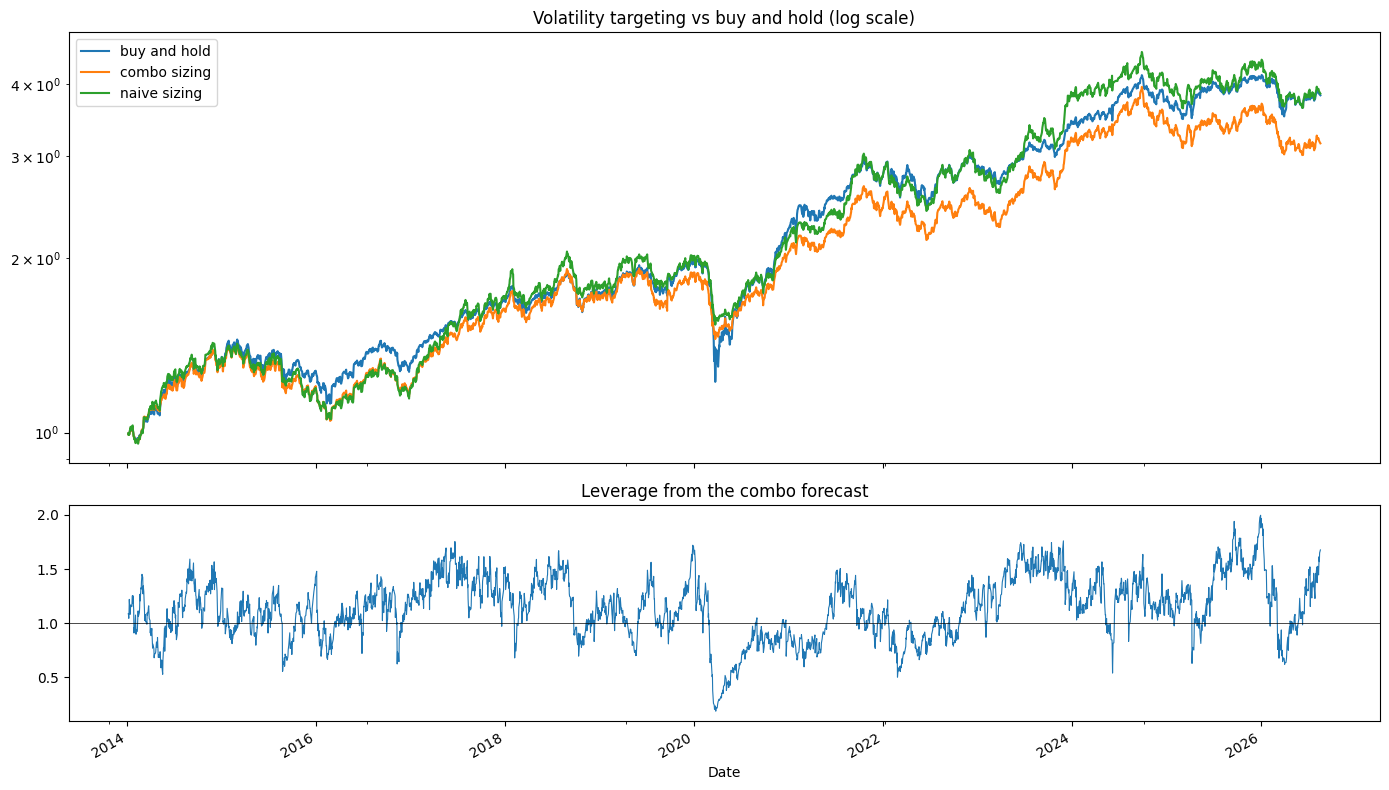

 target vol    cost   Sharpe   MaxDD %   CAGR %
       0.12     5bps     0.70     -21.1      8.0
       0.12    10bps     0.65     -21.6      7.4
       0.12    20bps     0.56     -22.4      6.1
       0.15     5bps     0.70     -25.9      9.9
       0.15    10bps     0.65     -26.4      9.0
       0.15    20bps     0.56     -27.4      7.4
       0.20     5bps     0.71     -33.3     12.9
       0.20    10bps     0.67     -33.9     11.9
       0.20    20bps     0.58     -35.1     10.0


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

curves = pd.DataFrame({"buy and hold": bt_combo["bh"],
                       "combo sizing": bt_combo["strat"],
                       "naive sizing": bt_naive["strat"]})
(1 + curves).cumprod().plot(ax=axes[0], logy=True)
axes[0].set_title("Volatility targeting vs buy and hold (log scale)")

bt_combo["lev_used"].plot(ax=axes[1], linewidth=0.8)
axes[1].axhline(1, color="black", linewidth=0.5)
axes[1].set_title("Leverage from the combo forecast")
plt.tight_layout()
plt.savefig(FIGDIR / "equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Does the result survive realistic costs?
print(f"{'target vol':>11}{'cost':>8}{'Sharpe':>9}{'MaxDD %':>10}{'CAGR %':>9}")
for tv in [0.12, 0.15, 0.20]:
    for c in [5, 10, 20]:
        s = perf(vol_target_backtest(wf, simple_ret, target_vol=tv,
                                     cost_bps=c)["strat"], "")
        print(f"{tv:>11.2f}{c:>6}bps{s['Sharpe']:>9.2f}"
              f"{s['MaxDD %']:>10.1f}{s['CAGR %']:>9.1f}")

### The edge does not survive

**Volatility targeting works. The better forecast does not add to it.** Sizing
by the free naive 20-day rolling volatility produces a higher Sharpe *and* a
higher CAGR than sizing by the combined model, at essentially the same drawdown,
and the best Calmar of any variant. The drawdown reduction versus buy and hold
is real — it comes from the *technique*, and any volatility estimate delivers it.

**Costs explain most of the gap.** The combined forecast moves every day, and
every move is a trade: about 15x annual turnover and roughly 9% of cumulative
return lost to costs at 5bps. The naive forecast is a 20-day moving average, so
it is mechanically smoother and trades far less. A model can be more accurate
and still lose on net, because the accuracy was bought with turnover.

**Sensitivity is severe.** Moving from 5bps to 20bps drops Sharpe by about a
fifth. Indian index futures cost perhaps 3-8bps round trip, but with slippage
10-15bps is the realistic planning number — close to where the advantage
disappears entirely.

**One variant is genuinely interesting: sizing by raw VIX.** It gives the lowest
maximum drawdown of anything tested, several points below both the model and the
naive estimate, at a Sharpe close to buy and hold. Because VIX prices scheduled
risk ahead of time, it cuts exposure *before* known events rather than after
realized volatility has already risen. It is also free and requires no fitting.

**And buy and hold still has the highest Sharpe of all.** Over 2014-2026 Nifty's
low-volatility periods were not reliably its high-return periods, so there was
limited Sharpe available to harvest through sizing at all — the quintile table
above shows how weak that relationship is.

> **Conclusion: do not trade the model.** A 27% QLIKE improvement over the
> baseline is real and statistically significant, and converts to nothing after
> costs. If the objective is drawdown control on Nifty, raw India VIX is the
> better sizing input: lower drawdown, no fitting, no research required.

---
# Part 8. Conclusions

### What the models found

1. **Direction is unpredictable, magnitude is not.** Return autocorrelations stay
   near zero at every lag; squared-return autocorrelation starts around 0.25 and
   is still positive at lag 40.

2. **A large share of Nifty variance is created overnight.** Parkinson and
   Garman-Klass both miss it, so either estimator understates Indian equity risk
   unless an overnight term is added.

3. **An insignificant coefficient was measurement noise, not absence of
   information.** The daily HAR term was insignificant with close-to-close
   features and strongly significant with Garman-Klass — the efficient estimator
   recovered a signal the noisy one had drowned.

4. **The leverage effect is sharply horizon-dependent.** In GJR-GARCH the
   asymmetry term is among the model's strongest parameters (p ~ 1e-12); as a
   20-day HAR feature the same effect is insignificant. Falls drive volatility
   tomorrow, not next month.

5. **Mean reversion showed up in three unrelated models**: GARCH's omega anchor,
   HAR's coefficient sum below 1, and a slope below 1 in a simple regression.

6. **India VIX carries an ~18% premium with a slope near 1.** The market prices
   the *shape* of volatility almost exactly right and charges a constant premium
   on top — the volatility risk premium, compensation for tail risk rather than
   an inefficiency.

7. **Implied and historical volatility fail on opposite risks.** VIX had one of
   its best years in 2024, when a scheduled election drove volatility, and its
   worst in 2020, when an unscheduled shock did. Historical models did the
   reverse. The complementarity is real but too unstable year to year to show up
   as a significant average improvement.

8. **Raw VIX roughly matches the entire modelling pipeline out-of-sample**, and
   de-biasing it made it slightly worse. One fitted parameter cost more than it
   earned.

9. **The in-sample ranking did not survive.** GARCH led in-sample and trailed
   out-of-sample; the HAR+VIX combination was clearly better than both components
   in-sample and statistically indistinguishable from them after walk-forward
   validation.

### What the money test found

10. **Statistical significance did not convert.** The combined model beat the
    baseline by 27% on QLIKE with a significant DM statistic, then lost to free
    naive sizing on Sharpe, CAGR and Calmar once ~15x turnover and costs were
    charged.

11. **The drawdown benefit belongs to the technique, not the model.** Volatility
    targeting cut max drawdown by about a third against buy and hold — and naive
    sizing delivered the same cut at lower cost.

12. **The best drawdown control came from raw VIX**, which requires no model at
    all. It cuts exposure ahead of scheduled risk instead of after realized
    volatility has already risen.

### Method notes worth keeping

- **The log-normal retransformation bias was worth ~6% of forecast level.**
  Adding sigma2/2 before exponentiating improved QLIKE by 8.4%, comparable to
  the entire gain from switching models. Always compare mean(forecast) with
  mean(actual) on a log-transformed target.
- **Overlapping windows destroy naive significance tests.** An uncorrected
  t-test returned t ~ 12 on a comparison whose HAC-corrected value was ~2.8.
- **A coefficient sign that contradicts economic logic means collinear features,
  not a broken model.** An early HAR built from three smoothings of the same
  20-day window produced a negative weekly coefficient.

### Limitations

- Single index; nothing here is tested on individual stocks or other markets.
- Annual refit cadence only. Turnover-aware sizing — rebalance bands or smoothed
  leverage — is the obvious next test, since costs rather than accuracy are what
  killed the strategy, and it was not attempted.
- Long-only, capped at 2x. Options-based expressions of a volatility view are
  untested.
- The backtest covers 2014-2026, a period dominated by a bull market and one
  extreme crash. Conclusions about volatility targeting are period-specific.